<a href="https://colab.research.google.com/github/shreya0246/Mobile-Programming-/blob/slt%2Fweek-2/PrescriptionReader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install python-Levenshtein --quiet

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import Levenshtein

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.2 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU available: []


In [3]:
from google.colab import files
import zipfile
import os
uploaded = files.upload()  # select your prescription dataset zip here

# Get the real filename you just uploaded (don't hardcode it)
zip_filename = list(uploaded.keys())[0]
print("Uploaded file:", zip_filename)

extract_path = '/content/rx_dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)

Saving prescription_dataset.zip to prescription_dataset.zip
Uploaded file: prescription_dataset.zip
Extracted to: /content/rx_dataset


In [4]:
# 3. Full recursive directory listing (so we can SEE the real structure, no guessing)
for root, dirs, files_ in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in files_[:5]:
        print(f"{indent}  {f}")
    if len(files_) > 5:
        print(f"{indent}  ... ({len(files_)} files total)")


rx_dataset/
  Doctor’s Handwritten Prescription BD dataset/
    Testing/
      testing_labels.csv
      testing_words/
        446.png
        267.png
        519.png
        7.png
        81.png
        ... (780 files total)
    Validation/
      validation_labels.csv
      validation_words/
        446.png
        267.png
        519.png
        7.png
        81.png
        ... (780 files total)
    Training/
      training_labels.csv
      training_words/
        2641.png
        2052.png
        446.png
        267.png
        802.png
        ... (3120 files total)


In [5]:
import glob

# 4. Find every CSV file inside the extracted dataset
csv_files = glob.glob(os.path.join(extract_path, '**', '*.csv'), recursive=True)
print(f"Found {len(csv_files)} CSV file(s):")
for c in csv_files:
    print(" -", c)

Found 3 CSV file(s):
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv


In [6]:
# 5. Auto-classify CSVs into train / validation / test based on filename/path
train_csv = next((c for c in csv_files if 'train' in c.lower()), None)
val_csv   = next((c for c in csv_files if 'valid' in c.lower()), None)
test_csv  = next((c for c in csv_files if 'test' in c.lower()), None)

print("TRAIN CSV:", train_csv)
print("VAL CSV  :", val_csv)
print("TEST CSV :", test_csv)

# If any of these show None, look at the printed CSV list above and set manually, e.g.:
# train_csv = csv_files[0]

TRAIN CSV: /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv
VAL CSV  : /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv
TEST CSV : /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv


In [7]:
# 6. Inspect a CSV to find the actual column names (varies slightly by dataset version)
sample_df = pd.read_csv(train_csv)
print("Columns found:", sample_df.columns.tolist())
sample_df.head()

Columns found: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol


In [8]:
# 7. Auto-detect the image-filename column and the label column
cols_lower = {c: c.lower() for c in sample_df.columns}

IMAGE_COL = next((c for c, cl in cols_lower.items() if 'image' in cl or 'file' in cl), sample_df.columns[0])
LABEL_COL = next((c for c, cl in cols_lower.items() if 'medicine' in cl or 'label' in cl or 'name' in cl or 'class' in cl), sample_df.columns[-1])

print("Detected IMAGE column:", IMAGE_COL)
print("Detected LABEL column:", LABEL_COL)
# If these look wrong after checking the printed head() above, set them manually, e.g.:
# IMAGE_COL = 'IMAGE'
# LABEL_COL = 'MEDICINE_NAME'

Detected IMAGE column: IMAGE
Detected LABEL column: MEDICINE_NAME


In [9]:
# 8. Find all image folders (any folder containing .jpg/.jpeg/.png files)
image_dirs = set()
for root, dirs, files_ in os.walk(extract_path):
    if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files_):
        image_dirs.add(root)

image_dirs = sorted(image_dirs)
print(f"Found {len(image_dirs)} folder(s) containing images:")
for d in image_dirs:
    n_imgs = len([f for f in os.listdir(d) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f" - {d}  ({n_imgs} images)")

Found 3 folder(s) containing images:
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_words  (780 images)
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words  (3120 images)
 - /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_words  (780 images)


In [10]:
# 9. Match each split (train/val/test) to its image folder automatically
def match_img_dir(csv_path, image_dirs):
    if csv_path is None:
        return None
    csv_dir_hint = os.path.dirname(csv_path).lower()
    # prefer a folder that shares the same parent directory as the csv
    candidates = [d for d in image_dirs if os.path.dirname(d).lower().startswith(os.path.dirname(csv_dir_hint)) or csv_dir_hint in d.lower()]
    if candidates:
        # choose the one with the most images (avoids picking an empty/near-empty subfolder)
        return max(candidates, key=lambda d: len(os.listdir(d)))
    return max(image_dirs, key=lambda d: len(os.listdir(d))) if image_dirs else None

train_img_dir = match_img_dir(train_csv, image_dirs)
val_img_dir   = match_img_dir(val_csv, image_dirs)
test_img_dir  = match_img_dir(test_csv, image_dirs)

print("TRAIN image dir:", train_img_dir)
print("VAL image dir  :", val_img_dir)
print("TEST image dir :", test_img_dir)

# IMPORTANT: double-check these against the Step 8 printout.
# If any is wrong, set it manually by copy-pasting the correct path from Step 8's output, e.g.:
# train_img_dir = image_dirs[0]

TRAIN image dir: /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words
VAL image dir  : /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words
TEST image dir : /content/rx_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words


In [11]:
# 10. Load all three CSVs and attach full image paths; drop rows where the image is missing
def load_split(csv_path, img_dir, image_col, label_col):
    if csv_path is None or img_dir is None:
        return pd.DataFrame(columns=['full_path', 'label'])
    df = pd.read_csv(csv_path)
    df['full_path'] = df[image_col].apply(lambda x: os.path.join(img_dir, str(x)))
    df['label'] = df[label_col].astype(str).str.strip()
    exists_mask = df['full_path'].apply(os.path.exists)
    missing = (~exists_mask).sum()
    if missing > 0:
        print(f"Warning: {missing} image(s) listed in {os.path.basename(csv_path)} were not found on disk and will be dropped.")
    return df[exists_mask][['full_path', 'label']].reset_index(drop=True)

train_df = load_split(train_csv, train_img_dir, IMAGE_COL, LABEL_COL)
val_df   = load_split(val_csv, val_img_dir, IMAGE_COL, LABEL_COL)
test_df  = load_split(test_csv, test_img_dir, IMAGE_COL, LABEL_COL)

print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Test samples :", len(test_df))
train_df.head()


Train samples: 3120
Val samples  : 780
Test samples : 780


,full_path,label
0,/content/rx_dataset/Doctor’s Handwritten Presc...,Aceta
1,/content/rx_dataset/Doctor’s Handwritten Presc...,Aceta
2,/content/rx_dataset/Doctor’s Handwritten Presc...,Aceta
3,/content/rx_dataset/Doctor’s Handwritten Presc...,Aceta
4,/content/rx_dataset/Doctor’s Handwritten Presc...,Aceta


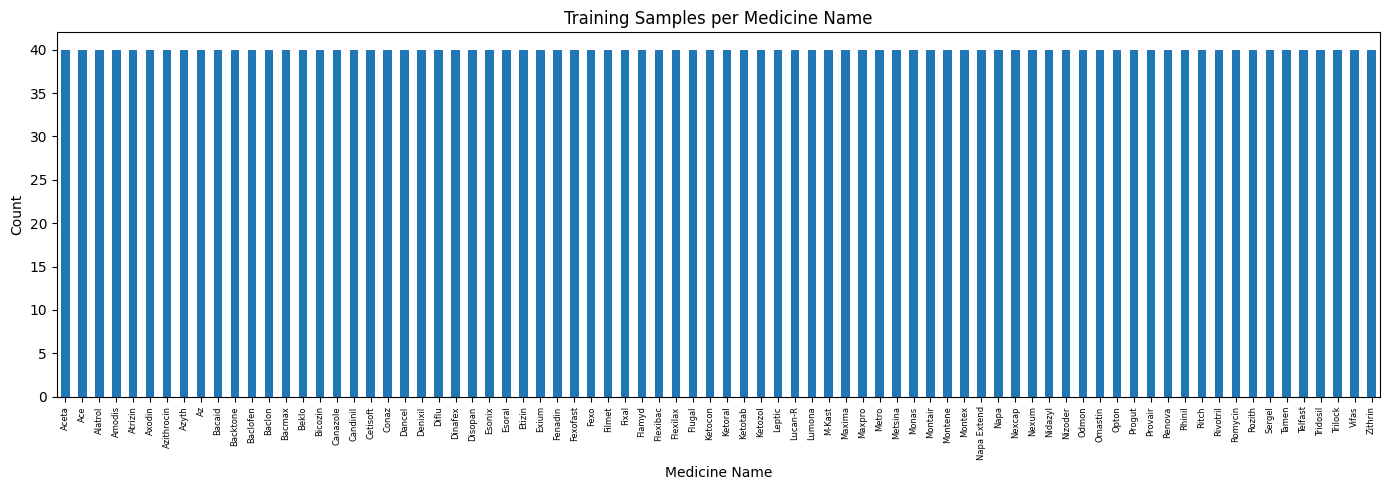

Total classes: 78
Most common : Aceta - 40 samples
Least common: Aceta - 40 samples


In [12]:
# 11. EDA - class distribution (how many samples per medicine name)
class_counts = train_df['label'].value_counts()

plt.figure(figsize=(14, 5))
class_counts.plot(kind='bar')
plt.title('Training Samples per Medicine Name')
plt.xlabel('Medicine Name')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

print("Total classes:", train_df['label'].nunique())
print("Most common :", class_counts.idxmax(), "-", class_counts.max(), "samples")
print("Least common:", class_counts.idxmin(), "-", class_counts.min(), "samples")


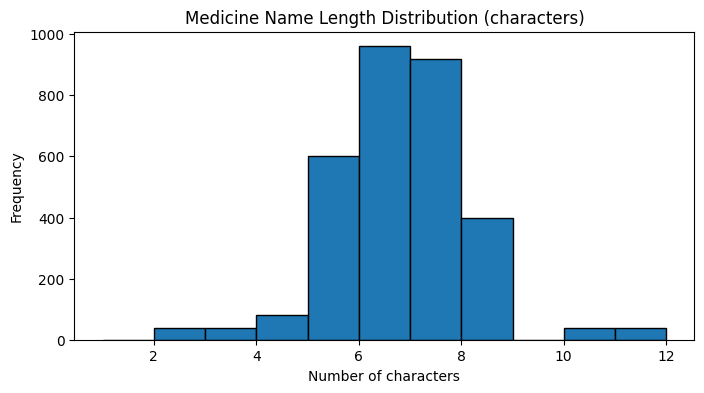

In [13]:
# 12. EDA - word length distribution
label_lengths = train_df['label'].apply(len)

plt.figure(figsize=(8, 4))
plt.hist(label_lengths, bins=range(1, label_lengths.max() + 2), edgecolor='black')
plt.title('Medicine Name Length Distribution (characters)')
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.show()


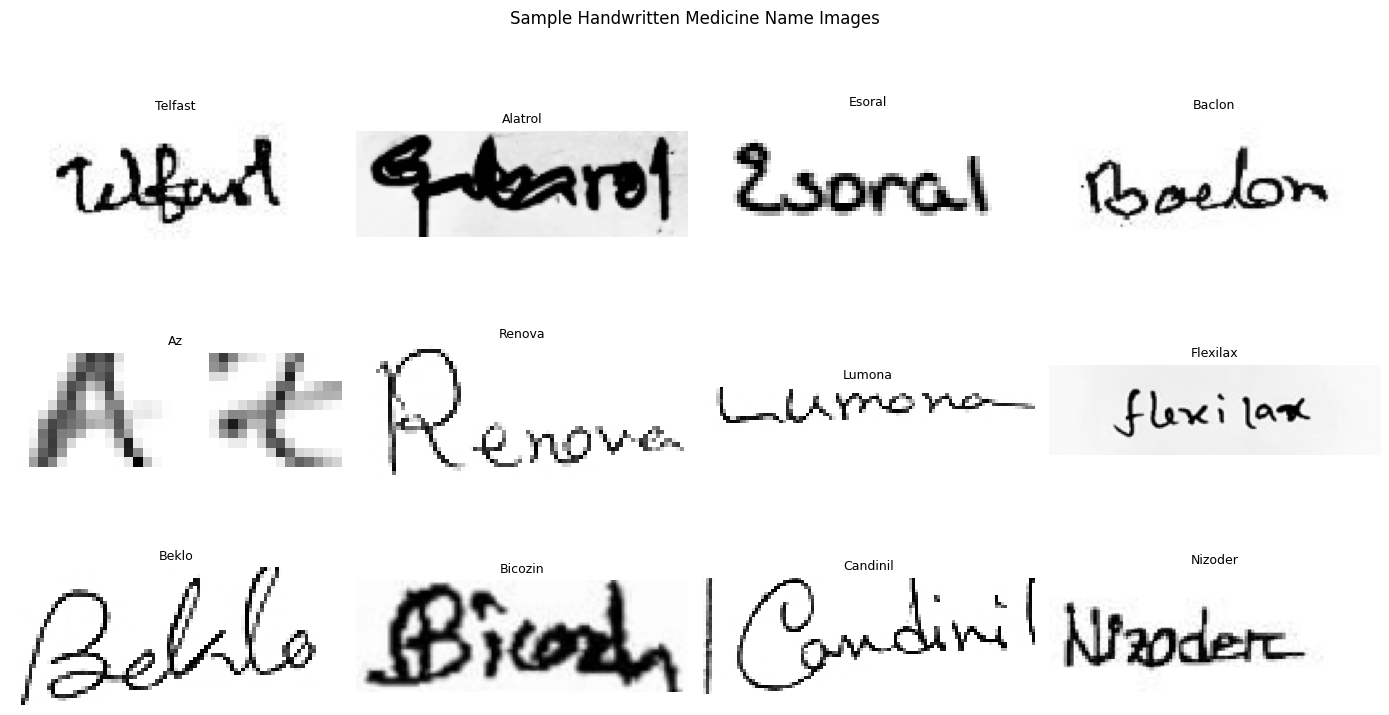

In [14]:
# 13. EDA - sample image grid with labels
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
sample_rows = train_df.sample(min(12, len(train_df)), random_state=1).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    if i >= len(sample_rows):
        ax.axis('off')
        continue
    row = sample_rows.iloc[i]
    img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(row['label'], fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Handwritten Medicine Name Images')
plt.tight_layout()
plt.show()


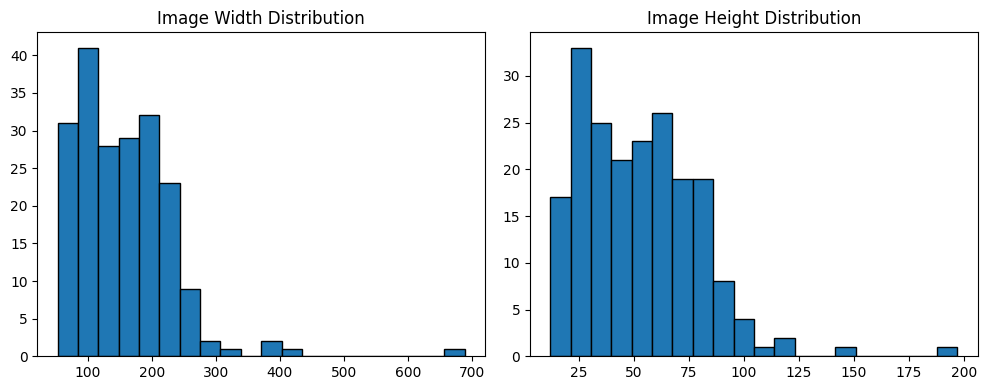

Width  range: 53-689, mean 155.9
Height range: 12-197, mean 52.7


In [15]:
# 14. EDA - image dimension spread (decides our resize target)
sample_paths = train_df['full_path'].sample(min(200, len(train_df)), random_state=42)
widths, heights = [], []
for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w); heights.append(h)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, edgecolor='black')
plt.title('Image Width Distribution')
plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, edgecolor='black')
plt.title('Image Height Distribution')
plt.tight_layout()
plt.show()

print(f"Width  range: {min(widths)}-{max(widths)}, mean {np.mean(widths):.1f}")
print(f"Height range: {min(heights)}-{max(heights)}, mean {np.mean(heights):.1f}")
